# Derivatives and hedging

Prices protection against a broken deal. The starting question - can Organon's own listed options be used to read the market's view - is tested directly against live data before doing anything else, since the answer determines the rest of the notebook.

In [1]:

import sys, warnings
sys.path.insert(0, r"/Users/shaan/Desktop/FAM/sunpharma-organon-merger-arbitrage")
warnings.filterwarnings("ignore")

from src import config as cfg, data, derivatives as deriv, viz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
pd.set_option("display.width", 160)
viz.apply_style()


## Can the OGN option chain be used?

Checked directly rather than assumed. If genuine, liquid quotes exist, market-implied volatility and an implied completion probability could be read straight off the chain instead of modelled.

In [2]:

def chain_diagnostics(ticker):
    tk = yf.Ticker(ticker)
    try:
        expiries = tk.options
    except Exception:
        return None
    if not expiries:
        return None
    spot = tk.history(period="1d")["Close"].iloc[-1]
    exp = expiries[0]
    calls = tk.option_chain(exp).calls
    atm = calls.iloc[(calls["strike"] - spot).abs().argsort()[:1]]
    return {
        "ticker": ticker, "spot": spot, "nearest_expiry": exp,
        "n_strikes": len(calls),
        "atm_bid": atm["bid"].iloc[0], "atm_ask": atm["ask"].iloc[0],
        "atm_open_interest": atm["openInterest"].iloc[0],
        "atm_implied_vol": atm["impliedVolatility"].iloc[0],
    }

rows = [chain_diagnostics(t) for t in [cfg.TARGET] + cfg.US_PEERS]
chain_check = pd.DataFrame([r for r in rows if r is not None]).set_index("ticker")
chain_check


,spot,nearest_expiry,n_strikes,atm_bid,atm_ask,atm_open_interest,atm_implied_vol
ticker,,,,,,,
OGN,13.570000,2026-08-21,5,0.0,0.0,34,0.062509
MRK,128.330002,2026-08-07,42,0.0,0.0,661,0.000010
PFE,25.809999,2026-08-07,26,0.0,0.0,20006,0.031260
VTRS,17.650000,2026-08-21,15,0.0,0.0,3682,0.031260
TEVA,34.720001,2026-08-07,28,0.0,0.0,4,0.000010


In [3]:

print("bid/ask of $0.00 and zero open interest at the at-the-money strike, across OGN and every")
print("large US pharma peer checked, is not an OGN-specific anomaly - it is yfinance's options feed")
print("being unusable for this purpose across the board. The 'implied volatility' field in these rows")
print("is a solver floor artifact (near 0%), not a market-clearing price. No model in this notebook")
print("is calibrated to this data. Derivative prices below are built from first principles instead -")
print("Black-Scholes and Greeks computed directly, using realised (not implied) volatility as the input.")


bid/ask of $0.00 and zero open interest at the at-the-money strike, across OGN and every
large US pharma peer checked, is not an OGN-specific anomaly - it is yfinance's options feed
being unusable for this purpose across the board. The 'implied volatility' field in these rows
is a solver floor artifact (near 0%), not a market-clearing price. No model in this notebook
is calibrated to this data. Derivative prices below are built from first principles instead -
Black-Scholes and Greeks computed directly, using realised (not implied) volatility as the input.


## Which volatility to use

The post-announcement realised volatility (4.46%, from the market-risk notebook) reflects a stock pinned to a pending cash deal - it is compressed *because* the market expects the deal to close, which is exactly the outcome being insured against. Using it to price deal-break protection is circular: it would price the insurance as if the very risk being covered barely exists. The pre-leak regime volatility (58.02%, the last clean read of Organon's standalone risk before deal speculation began) is used instead - both are shown side by side so the distortion is visible rather than hidden.

In [4]:

vol_pre_leak = 0.5802     # from the market-risk notebook's regime table
vol_post_ann = 0.0446     # shown for contrast only - not used to price anything below

spot = 13.57
offer = cfg.DEAL["offer_price_usd"]
r = 0.04617   # current 10Y UST, from the market-risk / valuation notebooks
T = (pd.Timestamp("2027-02-15") - pd.Timestamp(cfg.SNAPSHOT_DATE)).days / 365  # midpoint of "early 2027"

print(f"spot ${spot:.2f}, offer ${offer:.2f}, r={r:.3%}, T={T:.3f} years (to assumed close)")


spot $13.57, offer $14.00, r=4.617%, T=0.529 years (to assumed close)


## Protective put: two volatility scenarios

A put struck near the unaffected price ($6.90), priced first at the (correct) pre-leak volatility and then, for contrast, at the (wrong, circular) post-announcement volatility - to show numerically, not just assert, how large the distortion is.

In [5]:

K_put = 6.90

put_correct = deriv.bs_put(spot, K_put, r, vol_pre_leak, T)
put_circular = deriv.bs_put(spot, K_put, r, vol_post_ann, T)

print(f"put premium, K=${K_put:.2f}, priced at pre-leak vol ({vol_pre_leak:.1%})   : ${put_correct:.3f}")
print(f"put premium, K=${K_put:.2f}, priced at post-announcement vol ({vol_post_ann:.1%}) : ${put_circular:.3f}")
print(f"\nthe circular pricing understates the true cost of protection by "
      f"{(1 - put_circular/put_correct):.0%}")


put premium, K=$6.90, priced at pre-leak vol (58.0%)   : $0.080
put premium, K=$6.90, priced at post-announcement vol (4.5%) : $0.000

the circular pricing understates the true cost of protection by 100%


## Greeks

In [6]:

g_put = deriv.greeks(spot, K_put, r, vol_pre_leak, T, option_type="put")
g_call_atm = deriv.greeks(spot, spot, r, vol_pre_leak, T, option_type="call")

greeks_table = pd.DataFrame({
    f"put, K=${K_put:.2f} (pre-leak vol)": g_put,
    f"call, K=${spot:.2f} ATM (pre-leak vol)": g_call_atm,
}).T
greeks_table.round(4)


,delta,gamma,vega,theta,rho
"put, K=$6.90 (pre-leak vol)",-0.0306,0.0121,0.0068,-0.0010,-0.0026
"call, K=$13.57 ATM (pre-leak vol)",0.6060,0.0672,0.0380,-0.0064,0.0308


## Payoff diagrams

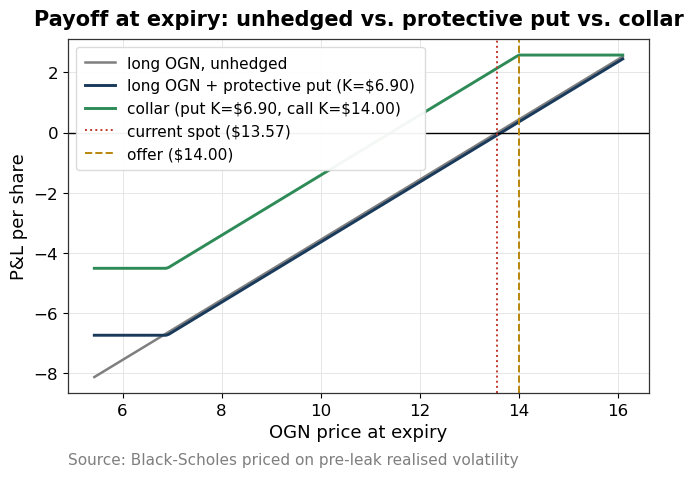

call premium sold, K=$14.00 (financing the collar) : $2.229
net cost of the collar                                     : $-2.149


In [7]:

spot_range = np.linspace(spot * 0.4, offer * 1.15, 200)

long_stock = deriv.long_stock_payoff(spot_range, spot)
protective_put = deriv.protective_put_payoff(spot_range, spot, K_put, put_correct)

call_K = offer
call_premium = deriv.bs_call(spot, call_K, r, vol_pre_leak, T)
collar = deriv.collar_payoff(spot_range, spot, K_put, put_correct, call_K, call_premium)

# NOTE: every '$' below is escaped as r'\$'. matplotlib treats a pair of
# unescaped '$' as mathtext delimiters, so a label like "put K=$6.90, call
# K=$14.00" silently renders as italic maths with the dollar signs stripped.
fig, ax = plt.subplots(figsize=viz.FIG_TALL)
ax.plot(spot_range, long_stock, label="long OGN, unhedged",
        color=viz.PALETTE["grey"], linewidth=1.8)
ax.plot(spot_range, protective_put,
        label=rf"long OGN + protective put (K=\${K_put:.2f})",
        color=viz.PALETTE["primary"], linewidth=2.1)
ax.plot(spot_range, collar,
        label=rf"collar (put K=\${K_put:.2f}, call K=\${call_K:.2f})",
        color=viz.PALETTE["accent"], linewidth=2.1)
ax.axhline(0, color="black", linewidth=1.0)
ax.axvline(spot, color=viz.PALETTE["secondary"], linestyle=":", linewidth=1.4,
           label=rf"current spot (\${spot:.2f})")
ax.axvline(offer, color=viz.PALETTE["gold"], linestyle="--", linewidth=1.4,
           label=rf"offer (\${offer:.2f})")
ax.set_xlabel("OGN price at expiry")
ax.set_ylabel("P&L per share")
ax.set_title("Payoff at expiry: unhedged vs. protective put vs. collar")
ax.legend(loc="upper left")
viz.source_note(ax, "Source: Black-Scholes priced on pre-leak realised volatility")
viz.save_chart(fig, "derivatives_payoff_diagrams", cfg.OUT_CHARTS)
plt.show()

print(f"call premium sold, K=${call_K:.2f} (financing the collar) : ${call_premium:.3f}")
print(f"net cost of the collar                                     : ${put_correct - call_premium:.3f}")


## Risk-neutral cross-check against the merger-arbitrage notebook

The expected-value framework from the portfolio notebook, restated in risk-neutral terms: discounting the probability-weighted payoff at the risk-free rate rather than simply comparing it to spot. Should be close to, though not identical to, the real-world spread-implied probability, since this uses the risk-free rate as the discount rate rather than the position's own required return.

In [8]:

p_market_implied = 0.9394   # from the merger-arbitrage notebook, unaffected-price basis
break_price = 6.90

rn_value = deriv.risk_neutral_deal_value(offer, break_price, p_market_implied, r, T)
print(f"risk-neutral present value at p={p_market_implied:.1%}: ${rn_value:.2f}  vs. spot ${spot:.2f}")
print(f"difference: ${rn_value - spot:+.2f}  ({(rn_value/spot - 1):+.2%})")
print()
print("A small remaining gap is expected: the spread-implied probability in the portfolio notebook was")
print("backed out using the position's OWN discount rate (implicitly, undiscounted-return breakeven),")
print("not the risk-free rate used here. The two are close, which is a reasonable cross-check, not an exact identity.")


risk-neutral present value at p=93.9%: $13.24  vs. spot $13.57
difference: $-0.33  (-2.41%)

A small remaining gap is expected: the spread-implied probability in the portfolio notebook was
backed out using the position's OWN discount rate (implicitly, undiscounted-return breakeven),
not the risk-free rate used here. The two are close, which is a reasonable cross-check, not an exact identity.


## Summary

In [9]:

summary = pd.Series({
    "option_chain_usable": False,
    "vol_used_for_pricing": vol_pre_leak,
    "put_premium_correct_vol": put_correct,
    "put_premium_circular_vol": put_circular,
    "circular_pricing_understatement_pct": 1 - put_circular/put_correct,
    "put_delta": g_put["delta"],
    "collar_net_cost": put_correct - call_premium,
    "risk_neutral_value_check": rn_value,
})
summary.to_csv(cfg.DATA_FINAL / "derivatives_summary.csv", header=["value"])
summary


option_chain_usable                        False
vol_used_for_pricing                      0.5802
put_premium_correct_vol                 0.079735
put_premium_circular_vol                     0.0
circular_pricing_understatement_pct          1.0
put_delta                              -0.030611
collar_net_cost                        -2.149285
risk_neutral_value_check               13.242471
dtype: object